In [1]:
using LinearAlgebra
using BenchmarkTools
using StochasticRounding
# using CUDA

function IR(A, b, x0; ul = Float16, u = Float32, ur = Float64, imax=10, atol=1e-5)

    x = x0

    for i in 1:imax
        # Step 1: compute residual in ur precision
        r = ur.(b) - ur.(A) * ur.(x)

        # Step 2: solve d in ul precision
        d = ul.(A) \ ul.(r)
        # d = cu.(ul.(A)) \ cu.(ul.(r)) # windows 
        
        # Step 3: update x in u precision
        x = u.(x) + u.(d)
        
        if abs(norm(r)) < atol
            println("Converged at iter $(i)")
            break
        end
    end

    return x
end

function SR(A, b, x0; ul = Float16, u = Float32, ur = Float64, imax=10, atol=1e-5)

    x = x0

    for i in 1:imax
        # Step 1: compute residual in ur precision
        r = ur.(b) - ur.(A) * ur.(x)

        # Step 2: solve d in SR low precision
        d = stochastic_round.(Float16sr, A) \ stochastic_round.(Float16sr, r)
        # d = cu.(ul.(A)) \ cu.(ul.(r)) # windows 
        
        # Step 3: update x in u precision
        x = u.(x) + u.(d)
        
        if abs(norm(r)) < atol
            println("Converged at iter $(i)")
            break
        end
    end

    return x
end

function example(n, m; ul = Float16, u = Float32, ur = Float64, imax=10, atol=1e-5)

    A = rand(n, m)
    b = rand(n)
    x0 = ones(m)

    start_time = time()
    x_true = A \ b
    elapsed = time() - start_time
    x_true = vec(x_true)
    println("Run time TRUE: ", elapsed)

    start_time = time()
    x = IR(A, b, x0)
    elapsed = time() - start_time
    println("Run time IR: ", elapsed)
    
    error = abs(norm(x-x_true))
    println("ALGO Error: ", error)

    # SR
    start_time = time()
    x = SR(A, b, x0)
    elapsed = time() - start_time
    println("SR Run time: ", elapsed)
    
    error = abs(norm(x-x_true))
    println("SR ALGO Error: ", error)
    
    println()

end    

example (generic function with 1 method)

In [2]:
using LinearAlgebra
using BenchmarkTools
using Random
using Plots
# using CUDA

Converged at iter 4
Converged at iter 4
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 4
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 5
Converged at iter 4
Converged at iter 5


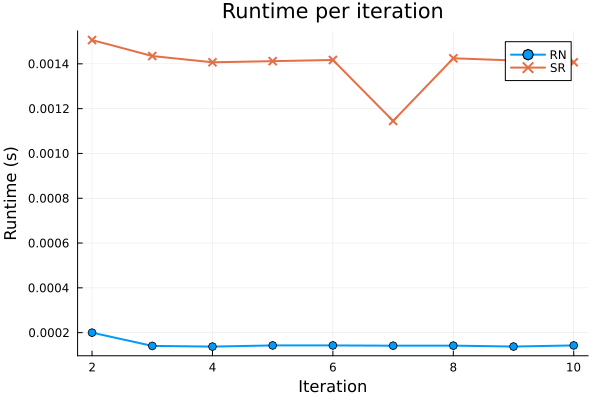

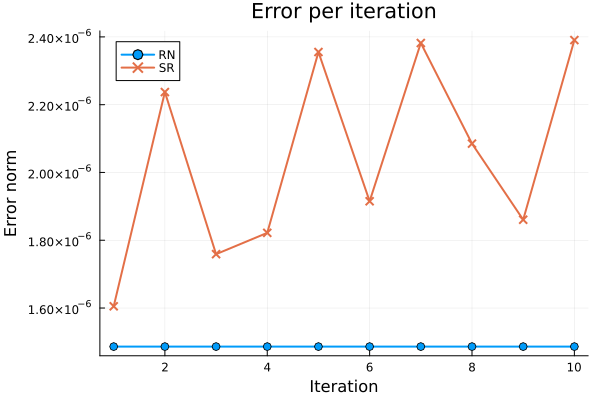

In [3]:
# plot run-time and error 
loop = 10

time_RN = zeros(loop)
time_SR = zeros(loop)
error_RN = zeros(loop)
error_SR = zeros(loop)

n, m = 50, 50
A = rand(n, m)
b = rand(n)
x0 = ones(m)
x_true = vec(A \ b)

for i in 1:loop
    # RN
    start_time = time()
    x = IR(A, b, x0)
    elapsed = time() - start_time
    time_RN[i] = elapsed

    error_RN[i] = norm(x - x_true)

    # SR
    start_time = time()
    x = SR(A, b, x0)
    elapsed = time() - start_time
    time_SR[i] = elapsed

    error_SR[i] = norm(x - x_true)
end

p_time = plot(2:loop, time_RN[2:end], label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Runtime (s)", title="Runtime per iteration")
plot!(p_time, 2:loop, time_SR[2:end], label="SR", lw=2, marker=:x)

p_err  = plot(1:loop, error_RN, label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Error norm", title="Error per iteration")
plot!(p_err, 1:loop, error_SR, label="SR", lw=2, marker=:x)

display(p_time)
display(p_err)

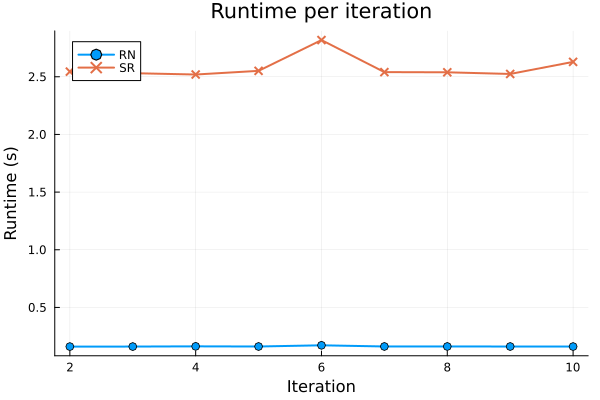

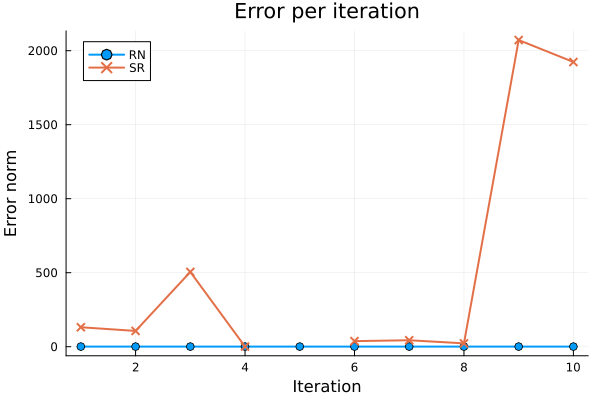

In [4]:
# plot run-time and error 
loop = 10

time_RN = zeros(loop)
time_SR = zeros(loop)
error_RN = zeros(loop)
error_SR = zeros(loop)

n, m = 500, 500
A = rand(n, m)
b = rand(n)
x0 = ones(m)
x_true = vec(A \ b)

for i in 1:loop
    # RN
    start_time = time()
    x = IR(A, b, x0)
    elapsed = time() - start_time
    time_RN[i] = elapsed

    error_RN[i] = norm(x - x_true)

    # SR
    start_time = time()
    x = SR(A, b, x0)
    elapsed = time() - start_time
    time_SR[i] = elapsed

    error_SR[i] = norm(x - x_true)
end

p_time = plot(2:loop, time_RN[2:end], label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Runtime (s)", title="Runtime per iteration")
plot!(p_time, 2:loop, time_SR[2:end], label="SR", lw=2, marker=:x)

p_err  = plot(1:loop, error_RN, label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Error norm", title="Error per iteration")
plot!(p_err, 1:loop, error_SR, label="SR", lw=2, marker=:x)

display(p_time)
display(p_err)

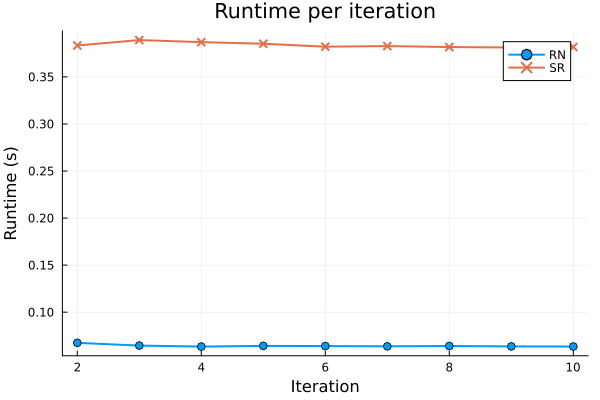

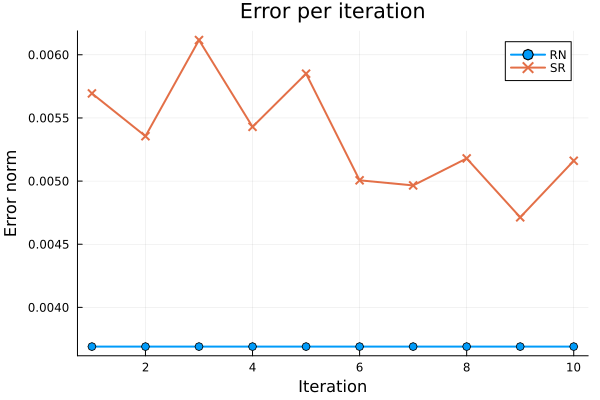

In [5]:
# plot run-time and error 
loop = 10

time_RN = zeros(loop)
time_SR = zeros(loop)
error_RN = zeros(loop)
error_SR = zeros(loop)

n, m = 500, 100
A = rand(n, m)
b = rand(n)
x0 = ones(m)
x_true = vec(A \ b)

for i in 1:loop
    # RN
    start_time = time()
    x = IR(A, b, x0)
    elapsed = time() - start_time
    time_RN[i] = elapsed

    error_RN[i] = norm(x - x_true)

    # SR
    start_time = time()
    x = SR(A, b, x0)
    elapsed = time() - start_time
    time_SR[i] = elapsed

    error_SR[i] = norm(x - x_true)
end

p_time = plot(2:loop, time_RN[2:end], label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Runtime (s)", title="Runtime per iteration")
plot!(p_time, 2:loop, time_SR[2:end], label="SR", lw=2, marker=:x)

p_err  = plot(1:loop, error_RN, label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Error norm", title="Error per iteration")
plot!(p_err, 1:loop, error_SR, label="SR", lw=2, marker=:x)

display(p_time)
display(p_err)

Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7
Converged at iter 7


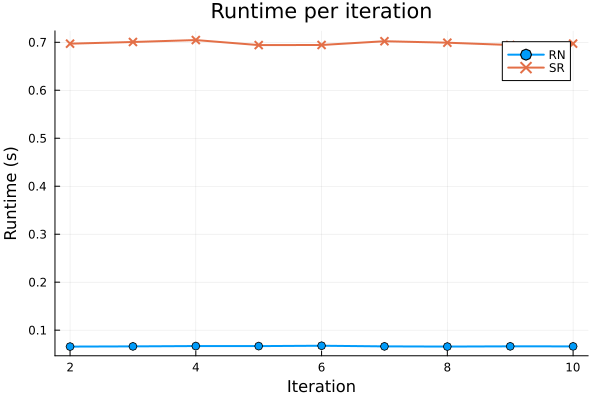

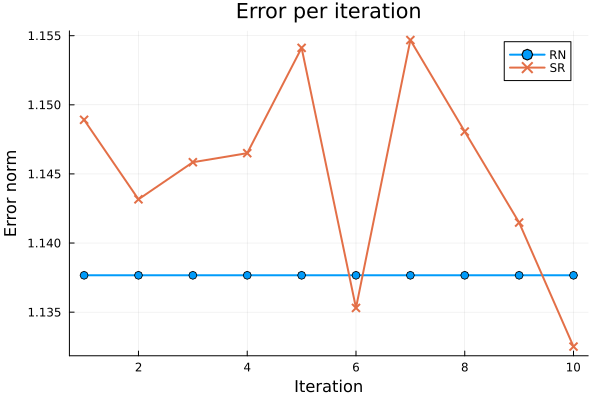

In [6]:
# plot run-time and error 
loop = 10

time_RN = zeros(loop)
time_SR = zeros(loop)
error_RN = zeros(loop)
error_SR = zeros(loop)

n, m = 100, 500
A = rand(n, m)
b = rand(n)
x0 = ones(m)
x_true = vec(A \ b)

for i in 1:loop
    # RN
    start_time = time()
    x = IR(A, b, x0)
    elapsed = time() - start_time
    time_RN[i] = elapsed

    error_RN[i] = norm(x - x_true)

    # SR
    start_time = time()
    x = SR(A, b, x0)
    elapsed = time() - start_time
    time_SR[i] = elapsed

    error_SR[i] = norm(x - x_true)
end

p_time = plot(2:loop, time_RN[2:end], label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Runtime (s)", title="Runtime per iteration")
plot!(p_time, 2:loop, time_SR[2:end], label="SR", lw=2, marker=:x)

p_err  = plot(1:loop, error_RN, label="RN", lw=2, marker=:o,
              xlabel="Iteration", ylabel="Error norm", title="Error per iteration")
plot!(p_err, 1:loop, error_SR, label="SR", lw=2, marker=:x)

display(p_time)
display(p_err)